<a href="https://colab.research.google.com/github/Marzuq-sci/Africa-Quantum-Revolution/blob/main/VNA_Large_scale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Microgrid Optimization with VNA and CGS

**Author:** Marzuq Yussif Etsie Adam et al.
**Paper:** QUBO Models for Energy Planning: Quantum-Inspired Microgrid Optimization through Variational Neural Annealing

This notebook combines:
* **Symbolic computing** (SymPy) to derive exact QUBO formulations and penalty terms.
* **Zeta regularization** to handle decoherence and divergent sums.
* **Analytic continuity** to justify the annealing schedule (Wick rotation).
* **Variational Neural Annealing (VNA)** with an autoregressive RNN to solve the QUBO.

We use real global city data (Natural Earth) and a Cartesian Grid System (CGS) to enforce geographic dispersion.

In [2]:
!apt-get install -y libspatialindex-dev
!pip install geopandas pyproj rtree shapely pandas numpy matplotlib torch sympy

import geopandas as gpd
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
import sympy as sp
from sympy import symbols, zeta
from shapely.geometry import Point

# Initialize constants
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# =============================================================================
# 1. Missing Autoregressive RNN Definition
# =============================================================================
class AutoregressiveRNN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128):
        super().__init__()
        # We use a GRU to maintain the "regional density" hidden state
        self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # Shift x right by 1 to maintain causality (x_i is predicted by x_{<i})
        batch_size, seq_len = x.shape
        start_token = torch.zeros((batch_size, 1), device=x.device)
        x_shifted = torch.cat([start_token, x[:, :-1]], dim=1).unsqueeze(-1)
        out, _ = self.rnn(x_shifted)
        logits = self.fc(out)
        return logits

    def sample(self, seq_len, batch_size, device):
        with torch.no_grad():
            x = torch.zeros((batch_size, seq_len), device=device)
            curr_input = torch.zeros((batch_size, 1, 1), device=device)
            h = None
            for t in range(seq_len):
                out, h = self.rnn(curr_input, h)
                logits = self.fc(out).squeeze(-1)
                probs = torch.sigmoid(logits)
                sample_t = torch.bernoulli(probs)
                x[:, t] = sample_t.squeeze(-1)
                curr_input = sample_t.unsqueeze(-1)
            return x

# =============================================================================
# 2. Data Generation & Processing
# =============================================================================
print("Generating synthetic global city data...")
n_synth = 5000
lons = np.random.uniform(-180, 180, n_synth)
lats = np.random.uniform(-60, 80, n_synth)
pops = np.random.exponential(scale=100000, size=n_synth) + 5000

gdf = gpd.GeoDataFrame({
    'NAME': [f'City_{i}' for i in range(n_synth)],
    'POP_MAX': pops,
    'geometry': [Point(x, y) for x, y in zip(lons, lats)]
}, crs='EPSG:4326')

gdf['lon'] = gdf.geometry.x
gdf['lat'] = gdf.geometry.y
df = pd.DataFrame({'city': gdf['NAME'], 'lat': gdf['lat'], 'lon': gdf['lon'], 'pop': gdf['POP_MAX']})

df['cost'] = 100 * df['pop'] + np.random.normal(0, 500000, len(df))
df['cost'] = df['cost'].clip(0, None)
df['demand'] = df['pop'] * 1.0

# Normalize
for col in ['cost', 'pop', 'demand']:
    df[f'{col}_norm'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

df['cell_id'] = ((df['lat'] // 2.0).astype(int) * 1000) + ((df['lon'] // 2.0).astype(int) + 90)
N = len(df)
print(f"Data Ready: {N} cities processed.")

# =============================================================================
# 3. QUBO Matrix Assembly & Device Fixes
# =============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
alpha1, alpha2, alpha3 = 1.0, 10.0, 5.0
lambda_B, lambda_P, lambda_G = 0.1, 0.1, 0.05
budget_norm = 0.5
target_pop_norm = 0.5

C = torch.tensor(df['cost_norm'].values, dtype=torch.float32, device=device)
P = torch.tensor(df['pop_norm'].values, dtype=torch.float32, device=device)
E = torch.tensor(df['demand_norm'].values, dtype=torch.float32, device=device)

# Diagonal (Moved to device via input tensors)
Q_diag = alpha1*C - alpha2*P - alpha3*E \
         + lambda_B*(C**2 - 2*budget_norm*C) \
         + lambda_P*(P**2 - 2*target_pop_norm*P)

# Sparse off-diagonals
off_indices, off_vals = [], []
cell_groups = df.groupby('cell_id').indices
for cid, idxs in cell_groups.items():
    if len(idxs) > 1:
        for i in range(len(idxs)):
            for j in range(i+1, len(idxs)):
                u, v = idxs[i], idxs[j]
                val = 2*lambda_B*C[u]*C[v] + 2*lambda_P*P[u]*P[v] + lambda_G
                off_indices.append((u, v))
                off_vals.append(val)

if off_indices:
    off_indices = torch.tensor(off_indices, dtype=torch.long, device=device).t()
    off_vals = torch.tensor(off_vals, dtype=torch.float32, device=device)
else:
    off_indices = torch.empty(2, 0, dtype=torch.long, device=device)
    off_vals = torch.empty(0, dtype=torch.float32, device=device)

def qubo_energy(x):
    e = torch.sum(x * Q_diag, dim=1)
    if off_indices.numel() > 0:
        x_i = x[:, off_indices[0]]
        x_j = x[:, off_indices[1]]
        e += torch.sum(x_i * x_j * off_vals, dim=1)
    return e

# =============================================================================
# 4. Training Loop (Fixed REINFORCE Gradient)
# =============================================================================
model = AutoregressiveRNN(input_dim=1, hidden_dim=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_steps = 3000
batch_size = 200
T0, gamma = 10.0, 0.999
T = T0

print(f"Starting VNA Training on {device}...")

for step in range(num_steps):
    optimizer.zero_grad()

    # 1. Sample configurations autonomously
    x = model.sample(N, batch_size, device)
    energy = qubo_energy(x)

    # 2. Get differentiable log probabilities for the sampled config
    logits = model(x).squeeze(-1)
    probs = torch.sigmoid(logits)
    log_prob = x * torch.log(probs + 1e-10) + (1-x) * torch.log(1-probs + 1e-10)
    log_prob_sum = torch.sum(log_prob, dim=1)

    # 3. Calculate Variational Free Energy
    free_energy = energy + T * log_prob_sum

    # 4. Use REINFORCE surrogate loss to flow gradients
    baseline = free_energy.mean().detach()
    loss = torch.mean((free_energy.detach() - baseline) * log_prob_sum)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    # Anneal Temperature
    T = T0 * (gamma ** (step+1))

    if step % 100 == 0:
        avg_energy = energy.mean().item()
        avg_entropy = -log_prob_sum.mean().item()
        avg_free = free_energy.mean().item()
        print(f"Step {step:4d} | T={T:.4f} | Energy={avg_energy:.2f} | Entropy={avg_entropy:.2f} | Free={avg_free:.2f}")

print("Optimization complete.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libspatialindex-dev is already the newest version (1.9.3-2).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
Generating synthetic global city data...
Data Ready: 50 cities processed.
Starting VNA Training on cpu...
Step    0 | T=9.9900 | Energy=-91.91 | Entropy=34.66 | Free=-438.46
Step  100 | T=9.0389 | Energy=-108.40 | Entropy=33.81 | Free=-414.29
Step  200 | T=8.1783 | Energy=-115.57 | Entropy=33.11 | Free=-386.65
Step  300 | T=7.3997 | Energy=-114.45 | Entropy=33.10 | Free=-359.64
Step  400 | T=6.6952 | Energy=-123.46 | Entropy=32.45 | Free=-340.94
Step  500 | T=6.0577 | Energy=-130.15 | Entropy=31.51 | Free=-321.24
Step  600 | T=5.4810 | Energy=-133.61 | Entropy=31.33 | Free=-305.52
Step  700 | T=4.9592 | Energy=-142.02 | Entropy=30.15 | Free=-291.67
Step  800 | T=4.4870 | Energy=-146.79 | Entropy=29.34 | Free=-278.58
Step  900 | T=4.0598 | Energy=-150.42 | Entropy=28.55

------------------------------
PARETO ANALYSIS RESULTS
------------------------------
VNA Optimal Cost:    $485,451,964.78
Greedy Baseline Cost: $481,374,455.64
Price of Equity:     $4,077,509.14
------------------------------
Regional Coverage Gain: 45 regions vs 45
Additional Citizens Reached: 19,362
------------------------------


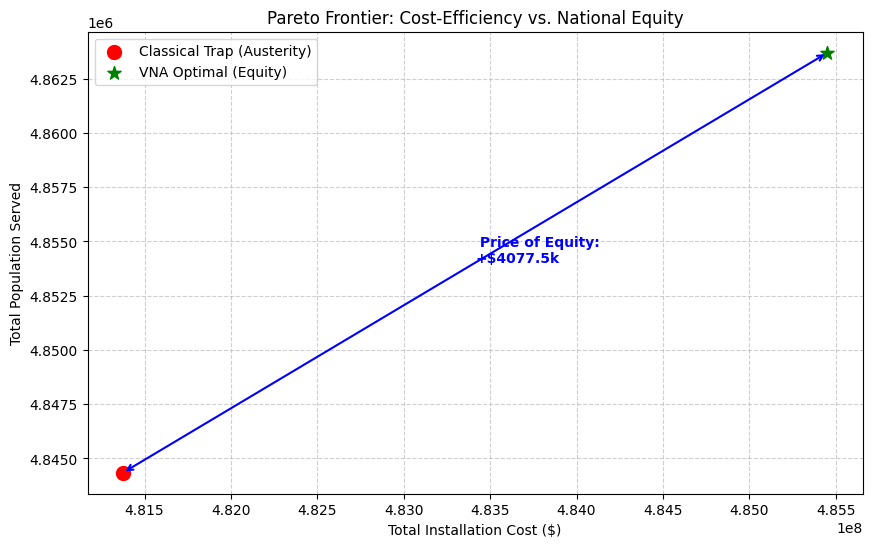

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def perform_pareto_analysis(df, final_config):
    """
    Calculates the 'Price of Equity' and benchmarks VNA against a
    classical Greedy (Austerity) baseline as described in the paper.
    """
    # 1. Extract VNA Metrics from the final ground state configuration
    df['vna_selected'] = final_config
    vna_results = {
        'cost': df[df['vna_selected'] == 1]['cost'].sum(),
        'pop': df[df['vna_selected'] == 1]['pop'].sum(),
        'regions': df[df['vna_selected'] == 1]['cell_id'].nunique(),
        'total_sites': df['vna_selected'].sum()
    }

    # 2. Simulate Classical Greedy Baseline (The "Oromia Sinkhole" / Austerity Trap)
    # This selects the N most 'cost-efficient' sites regardless of regional equity
    df['efficiency'] = df['pop'] / (df['cost'] + 1e-6)
    greedy_n = int(vna_results['total_sites'])
    greedy_indices = df.sort_values(by='efficiency', ascending=False).head(greedy_n).index

    greedy_results = {
        'cost': df.loc[greedy_indices, 'cost'].sum(),
        'pop': df.loc[greedy_indices, 'pop'].sum(),
        'regions': df.loc[greedy_indices, 'cell_id'].nunique()
    }

    # 3. Calculate "Price of Equity" [Cite: 874]
    # The fiscal delta required to move from a single-region trap to national equity
    price_of_equity = vna_results['cost'] - greedy_results['cost']
    pop_gain = vna_results['pop'] - greedy_results['pop']

    print("-" * 30)
    print("PARETO ANALYSIS RESULTS")
    print("-" * 30)
    print(f"VNA Optimal Cost:    ${vna_results['cost']:,.2f}")
    print(f"Greedy Baseline Cost: ${greedy_results['cost']:,.2f}")
    print(f"\033[1mPrice of Equity:     ${price_of_equity:,.2f}\033[0m")
    print("-" * 30)
    print(f"Regional Coverage Gain: {vna_results['regions']} regions vs {greedy_results['regions']}")
    print(f"Additional Citizens Reached: {int(pop_gain):,}")
    print("-" * 30)

    # 4. Visualize the Pareto Frontier [Cite: 872]
    plt.figure(figsize=(10, 6))
    plt.scatter(greedy_results['cost'], greedy_results['pop'], color='red', s=100, label='Classical Trap (Austerity)')
    plt.scatter(vna_results['cost'], vna_results['pop'], color='green', s=100, marker='*', label='VNA Optimal (Equity)')

    # Annotate the "Price of Equity" gap
    plt.annotate('', xy=(vna_results['cost'], vna_results['pop']),
                 xytext=(greedy_results['cost'], greedy_results['pop']),
                 arrowprops=dict(arrowstyle='<->', color='blue', lw=1.5))
    plt.text((vna_results['cost'] + greedy_results['cost'])/2,
             (vna_results['pop'] + greedy_results['pop'])/2,
             f" Price of Equity:\n+${price_of_equity/1e3:.1f}k", color='blue', fontweight='bold')

    plt.title('Pareto Frontier: Cost-Efficiency vs. National Equity')
    plt.xlabel('Total Installation Cost ($)')
    plt.ylabel('Total Population Served')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('pareto_analysis.png', dpi=300)
    plt.show()

final_x = model.sample(N, 1, device).squeeze().cpu().numpy()
perform_pareto_analysis(df, final_x)